In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load Dataset

df = pd.read_csv("heart_disease.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [3]:
# Check Dataset

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Shape:
(303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows:
1


In [4]:
# Check Target

print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)


Target Distribution:
target
1    165
0    138
Name: count, dtype: int64

Target Percentage:
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


In [5]:
# Separate X and y

X = df.drop("target", axis=1)
y = df["target"]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)


X Shape:
(303, 13)

y Shape:
(303,)


In [6]:
# Handle Missing Values

X = X.fillna(X.median())

print("\nMissing Values after Handling:")
print(X.isnull().sum().sum())


Missing Values after Handling:
0


In [7]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)


Training Data:
(242, 13)

Testing Data:
(61, 13)


In [8]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
# Logistic Regression without PCA

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred = logistic_model.predict(
    X_test_scaled
)

accuracy_without_pca = accuracy_score(
    y_test,
    y_pred
)

print("\nLogistic Regression without PCA:")
print("Accuracy:", accuracy_without_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


Logistic Regression without PCA:
Accuracy: 0.8032786885245902

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Confusion Matrix:
[[19  9]
 [ 3 30]]


In [10]:
# Apply PCA

pca = PCA(
    n_components=0.95
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print("\nPCA Results:")
print("Original Number of Features:", X_train.shape[1])
print("Number of PCA Components:", X_train_pca.shape[1])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())


PCA Results:
Original Number of Features: 13
Number of PCA Components: 12

Explained Variance Ratio:
[0.22234911 0.12029134 0.09826737 0.08756808 0.07461818 0.07153292
 0.06678805 0.05891434 0.05361    0.04924664 0.03995217 0.03234194]

Total Explained Variance:
0.975480154826315


In [11]:
# Logistic Regression with PCA

pca_model = LogisticRegression(
    max_iter=1000
)

pca_model.fit(
    X_train_pca,
    y_train
)

y_pred_pca = pca_model.predict(
    X_test_pca
)

accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_pca
)

print("\nLogistic Regression with PCA:")
print("Accuracy:", accuracy_with_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_pca
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_pca
    )
)


Logistic Regression with PCA:
Accuracy: 0.8032786885245902

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Confusion Matrix:
[[19  9]
 [ 3 30]]


In [12]:
# Compare Results

results = pd.DataFrame({
    "Model": [
        "Logistic Regression without PCA",
        "Logistic Regression with PCA"
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
                             Model  Accuracy
0  Logistic Regression without PCA  0.803279
1     Logistic Regression with PCA  0.803279


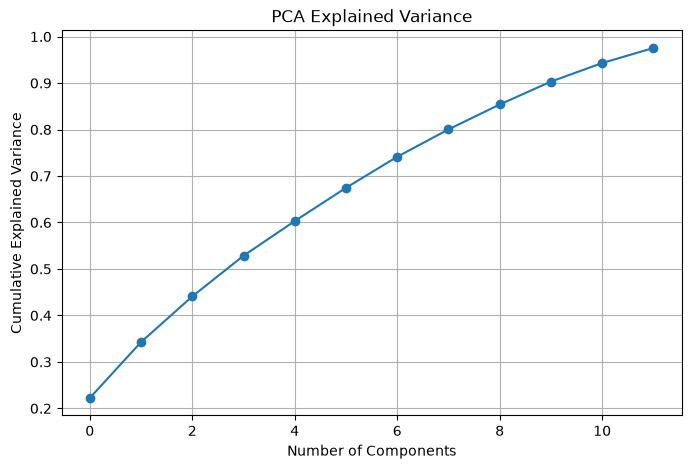

In [13]:
# PCA Explained Variance Plot

plt.figure(figsize=(8, 5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()

plt.show()

In [14]:
# Conclusion

print("\nConclusion:")

print(
    "PCA was used to reduce the number of features while "
    "retaining most of the important information."
)

print(
    "The features were standardized before applying PCA "
    "because PCA is affected by the scale of the variables."
)

print(
    "Logistic Regression was used for binary classification "
    "after PCA."
)

print(
    "The accuracy before and after PCA was compared to "
    "understand the effect of dimensionality reduction."
)


Conclusion:
PCA was used to reduce the number of features while retaining most of the important information.
The features were standardized before applying PCA because PCA is affected by the scale of the variables.
Logistic Regression was used for binary classification after PCA.
The accuracy before and after PCA was compared to understand the effect of dimensionality reduction.
